# v3 (dont use)

In [ ]:
!wget -q http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz
!mkdir -p /content/data/SpeechCommands/speech_commands_v0.01
!tar -xf speech_commands_v0.01.tar.gz -C /content/data/SpeechCommands/speech_commands_v0.01
!rm speech_commands_v0.01.tar.gz

In [42]:
import os
import random
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torchaudio.datasets import SPEECHCOMMANDS
from tqdm.auto import tqdm
from transformers import ASTFeatureExtractor, ASTForAudioClassification

In [37]:
TARGET_WORDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
LABELS = TARGET_WORDS + ["_silence_", "_unknown_"]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
NUM_CLASSES = 12
SAMPLE_RATE = 16000
CLIP_LEN = 16000

In [38]:
class SC12(Dataset):
    def __init__(self, root, subset, train_fraction=1.0, max_samples=None):
        self.base = SPEECHCOMMANDS(
            root=root,
            url="speech_commands_v0.01",
            folder_in_archive="SpeechCommands",
            download=False,
            subset=subset,
        )
        self.subset = subset

        # Bucket every sample into targets or unknowns
        targets_by_word = {w: [] for w in TARGET_WORDS}
        unknown_indices = []
        for i in range(len(self.base)):
            label = self.base.get_metadata(i)[2]
            if label in TARGET_WORDS:
                targets_by_word[label].append(i)
            elif label != "_background_noise_":
                unknown_indices.append(i)

        # If this is the training set, take only `train_fraction` of each class
        if subset == "training" and train_fraction < 1.0:
            rng = random.Random(42)
            for w in TARGET_WORDS:
                idxs = targets_by_word[w]
                rng.shuffle(idxs)
                keep = max(1, int(len(idxs) * train_fraction))
                targets_by_word[w] = idxs[:keep]
            rng.shuffle(unknown_indices)
            unknown_keep = max(1, int(len(unknown_indices) * train_fraction))
            unknown_indices = unknown_indices[:unknown_keep]

        # Flatten target indices
        self.target_indices = []
        for w in TARGET_WORDS:
            self.target_indices.extend(targets_by_word[w])

        # Match silence and unknown counts to the average target count
        avg_per_target = len(self.target_indices) // len(TARGET_WORDS)
        random.Random(0).shuffle(unknown_indices)
        self.unknown_indices = unknown_indices[:avg_per_target]
        self.n_silence = avg_per_target

        # --- Cap total samples to max_samples while preserving class distribution ---
        if max_samples is not None:
            # There are (len(TARGET_WORDS) + 2) classes: one per target word + unknown + silence
            n_classes = len(TARGET_WORDS) + 2
            per_class = max(1, max_samples // n_classes)

            # Cap each target word proportionally
            rng = random.Random(7)
            new_target_indices = []
            for w in TARGET_WORDS:
                # Gather indices belonging to this word
                word_indices = [
                    i for i in self.target_indices
                    if self.base.get_metadata(i)[2] == w
                ]
                rng.shuffle(word_indices)
                new_target_indices.extend(word_indices[:per_class])
            self.target_indices = new_target_indices

            # Cap unknown and silence to the same per_class budget
            unknown_list = list(self.unknown_indices)
            rng.shuffle(unknown_list)
            self.unknown_indices = unknown_list[:per_class]
            self.n_silence = per_class

        # Load background noise clips
        bg_dir = os.path.join(self.base._path, "_background_noise_")
        self.bg_clips = []
        for f in sorted(os.listdir(bg_dir)):
            if f.endswith(".wav"):
                wav, sr = torchaudio.load(os.path.join(bg_dir, f))
                self.bg_clips.append(wav.squeeze(0))

        # For val/test, use a fixed silence plan so evaluation is deterministic
        self.silence_plan = None
        if subset != "training":
            rng = random.Random(123)
            self.silence_plan = []
            for _ in range(self.n_silence):
                bi = rng.randrange(len(self.bg_clips))
                max_start = self.bg_clips[bi].size(0) - CLIP_LEN
                start = rng.randrange(max(1, max_start))
                scale = rng.uniform(0.0, 0.1)
                self.silence_plan.append((bi, start, scale))

    def __len__(self):
        return len(self.target_indices) + len(self.unknown_indices) + self.n_silence

    def pad_or_trim(self, wav):
        if wav.size(0) < CLIP_LEN:
            pad_amount = CLIP_LEN - wav.size(0)
            return torch.nn.functional.pad(wav, (0, pad_amount))
        return wav[:CLIP_LEN]

    def __getitem__(self, idx):
        n_targets = len(self.target_indices)
        n_unknowns = len(self.unknown_indices)

        # Target word
        if idx < n_targets:
            wav, _, label, _, _ = self.base[self.target_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX[label]

        # Unknown word
        idx -= n_targets
        if idx < n_unknowns:
            wav, _, _, _, _ = self.base[self.unknown_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX["_unknown_"]

        # Silence (background noise crop)
        idx -= n_unknowns
        if self.silence_plan is not None:
            bi, start, scale = self.silence_plan[idx]
        else:
            bi = random.randrange(len(self.bg_clips))
            max_start = self.bg_clips[bi].size(0) - CLIP_LEN
            start = random.randrange(max(1, max_start))
            scale = random.uniform(0.0, 0.1)
        wav = self.bg_clips[bi][start:start + CLIP_LEN] * scale
        wav = self.pad_or_trim(wav)
        return wav, LABEL2IDX["_silence_"]

In [43]:
def make_ast_collate(feature_extractor):
    def collate(batch):
        wavs, labels = zip(*batch)
        wavs_np = [w.numpy() for w in wavs]
        inputs = feature_extractor(wavs_np, sampling_rate=SAMPLE_RATE, return_tensors="pt")
        inputs["labels"] = torch.tensor(labels, dtype=torch.long)
        return inputs
    return collate


def make_kwt_collate():
    mfcc = torchaudio.transforms.MFCC(
        sample_rate=SAMPLE_RATE,
        n_mfcc=40,
        melkwargs={"n_fft": 480, "hop_length": 160, "n_mels": 40},
    )

    def collate(batch):
        wavs, labels = zip(*batch)
        wavs = torch.stack(wavs)
        feats = mfcc(wavs)                     # (B, 40, 101)
        feats = feats.transpose(1, 2)          # (B, 101, 40)
        return feats, torch.tensor(labels)
    return collate

In [44]:
def train_one_epoch_ast(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in tqdm(loader, desc="train", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch["labels"]

        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.logits.argmax(-1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_ast(model, loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in tqdm(loader, desc="eval", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch["labels"]
        outputs = model(**batch)

        total_loss += outputs.loss.item() * labels.size(0)
        correct += (outputs.logits.argmax(-1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


In [ ]:
feature_extractor.do_normalize = False  # we set normalization to False in order to calculate the mean + std of the dataset
mean = []
std = []

# we use the transformation w/o augmentation on the training dataset to calculate the mean + std
dataset["train"].set_transform(preprocess_audio, output_all_columns=False)
for i, (audio_input, labels) in enumerate(dataset["train"]):
    cur_mean = torch.mean(dataset["train"][i][audio_input])
    cur_std = torch.std(dataset["train"][i][audio_input])
    mean.append(cur_mean)
    std.append(cur_std)
feature_extractor.mean = np.mean(mean)
feature_extractor.std = np.mean(std)
feature_extractor.do_normalize = True


def compute_dataset_stats(dataset, feature_extractor):
    all_means = []
    all_stds = []
    feature_extractor.do_normalize = False
    for x, _ in dataset:
        inputs = feature_extractor(
            x,
            sampling_rate=16000,
            return_tensors="pt"
        )
        feats = inputs["input_values"]  # shape: (1, time, freq)

        all_means.append(feats.mean().item())
        all_stds.append(feats.std().item())

    mean = sum(all_means) / len(all_means)
    std = sum(all_stds) / len(all_stds)
    return mean, std

In [45]:
def train_ast(train_ds, val_ds, test_ds, device, epochs=3, batch_size=8, lr=1e-5):
    model_id = "MIT/ast-finetuned-audioset-10-10-0.4593"
    feature_extractor = ASTFeatureExtractor.from_pretrained(model_id)
    mean, std = compute_dataset_stats(train_ds, feature_extractor)
    feature_extractor.mean = mean
    feature_extractor.std = std
    feature_extractor.do_normalize = True

    model = ASTForAudioClassification.from_pretrained(
        model_id,
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True,
    )
    model.gradient_checkpointing_enable()   # save GPU memory
    model.to(device)

    collate = make_ast_collate(feature_extractor)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              collate_fn=collate, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            collate_fn=collate, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             collate_fn=collate, num_workers=2)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_val_acc = 0.0
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch_ast(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate_ast(model, val_loader, device)
        print(f"[AST] epoch {epoch} | train loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| val loss {val_loss:.4f} acc {val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            # torch.save(model.state_dict(), "ast_best.pt")

    # model.load_state_dict(torch.load("ast_best.pt", map_location=device))
    # test_loss, test_acc = evaluate_ast(model, test_loader, device)
    # print(f"[AST] TEST loss {test_loss:.4f} acc {test_acc:.4f}")
    return model

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
root="/content/data"
train_ds = SC12(root, "training", train_fraction=0.1)
val_ds = SC12(root, "validation", max_samples=1000)
test_ds = SC12(root, "testing",  max_samples=800)
print(f"train: {len(train_ds)}   val: {len(val_ds)}   test: {len(test_ds)}")


device: cuda
train: 2220   val: 3091   test: 3079


In [47]:
train_ast(train_ds, val_ds, test_ds, device)

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                        
------------------------+----------+----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([12])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([12, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


train:   0%|          | 0/278 [00:00<?, ?it/s]

eval:   0%|          | 0/387 [00:00<?, ?it/s]

[AST] epoch 1 | train loss 1.2074 acc 0.6095 | val loss 0.6918 acc 0.7807


train:   0%|          | 0/278 [00:00<?, ?it/s]

KeyboardInterrupt: 

# v4

In [1]:
!wget -q http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz
!mkdir -p /content/data/SpeechCommands/speech_commands_v0.01
!tar -xf speech_commands_v0.01.tar.gz -C /content/data/SpeechCommands/speech_commands_v0.01
!rm speech_commands_v0.01.tar.gz

In [3]:
import torch
from transformers import (
    ASTFeatureExtractor,
    ASTForAudioClassification,
    TrainingArguments,
    Trainer,
)
from torch.optim import Adam
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR
import numpy as np
import os
import random
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torchaudio.datasets import SPEECHCOMMANDS
from tqdm.auto import tqdm
import json
# import evaluate

In [20]:
TARGET_WORDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
LABELS = TARGET_WORDS + ["unknown", "silence"]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
NUM_CLASSES = 12
SAMPLE_RATE = 16000
CLIP_LEN = 16000

class SC12(Dataset):
    def __init__(self, root, subset, train_fraction=1.0, valid_fraction=1.0, test_fraction=1.0):
        """
        Args:
            root:             Dataset root directory.
            subset:           One of "training", "validation", "testing".
            train_fraction:   Fraction of training data to keep (0.0–1.0).
            valid_fraction:   Fraction of validation data to keep (0.0–1.0).
            test_fraction:    Fraction of test data to keep (0.0–1.0).
        """
        self.base = SPEECHCOMMANDS(
            root=root,
            url="speech_commands_v0.01",
            folder_in_archive="SpeechCommands",
            download=False,
            subset=subset,
        )
        self.subset = subset

        # Pick the right fraction for this split
        fraction = {"training": train_fraction, "validation": valid_fraction, "testing": test_fraction}[subset]

        # Bucket every sample into targets or unknowns
        targets_by_word = {w: [] for w in TARGET_WORDS}
        unknown_indices = []
        for i in range(len(self.base)):
            label = self.base.get_metadata(i)[2]
            if label in TARGET_WORDS:
                targets_by_word[label].append(i)
            elif label != "_background_noise_":
                unknown_indices.append(i)

        # Apply fraction per class (all splits)
        rng = random.Random(42)
        for w in TARGET_WORDS:
            idxs = targets_by_word[w]
            rng.shuffle(idxs)
            keep = max(1, int(len(idxs) * fraction))
            targets_by_word[w] = idxs[:keep]
        rng.shuffle(unknown_indices)
        unknown_indices = unknown_indices[:max(1, int(len(unknown_indices) * fraction))]

        # Flatten target indices
        self.target_indices = []
        for w in TARGET_WORDS:
            self.target_indices.extend(targets_by_word[w])

        # Match silence and unknown counts to the average target count
        avg_per_target = len(self.target_indices) // len(TARGET_WORDS)
        random.Random(0).shuffle(unknown_indices)
        self.unknown_indices = unknown_indices[:avg_per_target]
        self.n_silence = avg_per_target

        # Load background noise clips
        bg_dir = os.path.join(self.base._path, "_background_noise_")
        self.bg_clips = []
        for f in sorted(os.listdir(bg_dir)):
            if f.endswith(".wav"):
                wav, sr = torchaudio.load(os.path.join(bg_dir, f))
                self.bg_clips.append(wav.squeeze(0))

        # For val/test, use a fixed silence plan so evaluation is deterministic
        self.silence_plan = None
        if subset != "training":
            rng = random.Random(123)
            self.silence_plan = []
            for _ in range(self.n_silence):
                bi = rng.randrange(len(self.bg_clips))
                max_start = self.bg_clips[bi].size(0) - CLIP_LEN
                start = rng.randrange(max(1, max_start))
                scale = rng.uniform(0.0, 0.1)
                self.silence_plan.append((bi, start, scale))

    def __len__(self):
        return len(self.target_indices) + len(self.unknown_indices) + self.n_silence

    def pad_or_trim(self, wav):
        if wav.size(0) < CLIP_LEN:
            pad_amount = CLIP_LEN - wav.size(0)
            return torch.nn.functional.pad(wav, (0, pad_amount))
        return wav[:CLIP_LEN]

    def __getitem__(self, idx):
        n_targets = len(self.target_indices)
        n_unknowns = len(self.unknown_indices)

        if idx < n_targets:
            wav, _, label, _, _ = self.base[self.target_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX[label]

        idx -= n_targets
        if idx < n_unknowns:
            wav, _, _, _, _ = self.base[self.unknown_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX["unknown"]

        idx -= n_unknowns
        if self.silence_plan is not None:
            bi, start, scale = self.silence_plan[idx]
        else:
            bi = random.randrange(len(self.bg_clips))
            max_start = self.bg_clips[bi].size(0) - CLIP_LEN
            start = random.randrange(max(1, max_start))
            scale = random.uniform(0.0, 0.1)
        wav = self.bg_clips[bi][start:start + CLIP_LEN] * scale
        wav = self.pad_or_trim(wav)
        return wav, LABEL2IDX["silence"]


def make_ast_collate(feature_extractor):
    def collate(batch):
        wavs, labels = zip(*batch)
        wavs_np = [w.numpy() for w in wavs]
        inputs = feature_extractor(wavs_np, sampling_rate=SAMPLE_RATE, return_tensors="pt")
        inputs["labels"] = torch.tensor(labels, dtype=torch.long)
        return inputs
    return collate

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
root="/content/data"

# original split: train ~22 000, valid 3091, test: 3079
train_ds = SC12(root, "training", train_fraction=0.1)
val_ds = SC12(root, "validation", valid_fraction=0.66)
test_ds = SC12(root, "testing",  test_fraction=0.66)

print(f"train {len(train_ds)}")
print(f"valid {len(val_ds)}")
print(f"test {len(test_ds)}")


device: cuda
train 2220
valid 2034
test 2024


In [22]:
def compute_dataset_stats(dataset, feature_extractor, n_samples=2000):
    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    feature_extractor.do_normalize = False

    all_means, all_stds = [], []
    for i in indices:
        x, _ = dataset[i]
        feats = feature_extractor(x.numpy(), sampling_rate=16000, return_tensors="pt")["input_values"]
        all_means.append(feats.mean().item())
        all_stds.append(feats.std().item())

    return sum(all_means) / len(all_means), sum(all_stds) / len(all_stds)

In [23]:
MODEL_ID = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_ID)
mean, std = compute_dataset_stats(train_ds, feature_extractor)
# !! Compute these from YOUR dataset, or fall back to AudioSet defaults
# from transformers import ASTFeatureExtractor
feature_extractor.mean = mean
feature_extractor.std  = std
feature_extractor.do_normalize = True
collate = make_ast_collate(feature_extractor)

In [35]:
# dont run unless you want to clean the gpu
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
# del model, trainer

NameError: name 'model' is not defined

In [27]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
# ── 1. Labels ────────────────────────────────────────────────────────────────
label2id = {
    "yes": 0, "no": 1, "up": 2, "down": 3, "left": 4,
    "right": 5, "on": 6, "off": 7, "stop": 8, "go": 9,
    "unknown": 10, "silence": 11,
}
id2label = {v: k for k, v in label2id.items()}
num_labels = 12

# ── 2. Feature extractor ──────────────────────────────────────────────────────
# MODEL_ID = "MIT/ast-finetuned-audioset-10-10-0.4593"
# feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_ID)
# mean, std = compute_dataset_stats(train_ds, feature_extractor)
# # !! Compute these from YOUR dataset, or fall back to AudioSet defaults
# # from transformers import ASTFeatureExtractor
# feature_extractor.mean = mean
# feature_extractor.std  = std
# feature_extractor.do_normalize = True
# collate = make_ast_collate(feature_extractor)

# TARGET_WORDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
# LABELS = TARGET_WORDS + ["silence", "unknown"]
# LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
# ── 3. Model ──────────────────────────────────────────────────────────────────
model = ASTForAudioClassification.from_pretrained(
    MODEL_ID,
    num_labels=12,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # replaces the 527-class AudioSet head
)

# ── 4. Preprocessing ──────────────────────────────────────────────────────────
def preprocess(batch):
    wavs = [np.array(a["array"], dtype=np.float32) for a in batch["audio"]]
    inputs = feature_extractor(
        wavs,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True,
    )
    inputs["labels"] = torch.tensor(
        [label2id[l] for l in batch["label"]], dtype=torch.long
    )
    return inputs

# ── 5. Metrics ────────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

# ── 6. Training arguments ─────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./ast-speech-commands",

    per_device_train_batch_size=16,   # down from 32
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=8,    # keep effective batch = 128

    gradient_checkpointing=True,      # trades compute for memory
    # LR & scheduler
    learning_rate=2.5e-4,
    lr_scheduler_type="cosine",         # we handle decay manually via callback
    warmup_ratio=1/8,                    # ~1 epoch warmup for 20 epochs

    # Duration
    num_train_epochs=8,

    # Precision — critical for T4 memory
    fp16=True,

    # Regularization
    weight_decay=0.0001,

    # Eval & saving
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=3,

    # Logging
    logging_steps=10,              # log every 10 steps
    logging_strategy="steps",      # make sure it logs during training

    report_to="none",                     # swap to "tensorboard" if you want
)

# ── 7. Step-decay scheduler callback (paper recipe: ×0.85 per epoch after ep5)
# from transformers import TrainerCallback

# class StepDecayCallback(TrainerCallback):
#     def __init__(self, decay_factor=0.85, start_epoch=5):
#         self.decay = decay_factor
#         self.start = start_epoch

#     def on_epoch_begin(self, args, state, control, **kwargs):
#         epoch = int(state.epoch or 0)
#         if epoch >= self.start:
#             for pg in kwargs["optimizer"].param_groups:
#                 pg["lr"] *= self.decay
#             print(f"Epoch {epoch}: LR decayed to {kwargs['optimizer'].param_groups[0]['lr']:.2e}")

# ── 8. Trainer ────────────────────────────────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,          # your HF dataset split
    eval_dataset=val_ds,
    data_collator=collate,
    compute_metrics=compute_metrics
)

# trainer.train()

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                        
------------------------+----------+----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([12])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([12, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [28]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,2.208002,0.962356,0.678466
2,0.572155,0.548487,0.830383
3,0.213834,0.450495,0.871681
4,0.117431,0.584149,0.842675
5,0.051701,0.524673,0.875123
6,0.036618,0.591395,0.869223
7,0.014553,0.451489,0.900197
8,0.003407,0.454020,0.898722


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=144, training_loss=0.3290581091100143, metrics={'train_runtime': 2153.1717, 'train_samples_per_second': 8.248, 'train_steps_per_second': 0.067, 'total_flos': 1.203930642996265e+18, 'train_loss': 0.3290581091100143, 'epoch': 8.0})

In [29]:
trainer.state.log_history  # list of dicts with loss, eval_loss, eval_accuracy, epoch

[{'loss': 2.208002471923828,
  'grad_norm': 9.775382995605469,
  'learning_rate': 0.000125,
  'epoch': 0.5755395683453237,
  'step': 10},
 {'eval_loss': 0.9623557329177856,
  'eval_accuracy': 0.6784660766961652,
  'eval_runtime': 53.9755,
  'eval_samples_per_second': 37.684,
  'eval_steps_per_second': 2.371,
  'epoch': 1.0,
  'step': 18},
 {'loss': 0.9444957733154297,
  'grad_norm': 5.999566555023193,
  'learning_rate': 0.000249961147750102,
  'epoch': 1.1151079136690647,
  'step': 20},
 {'loss': 0.5721550941467285,
  'grad_norm': 5.489796161651611,
  'learning_rate': 0.0002453280308687515,
  'epoch': 1.6906474820143886,
  'step': 30},
 {'eval_loss': 0.5484873652458191,
  'eval_accuracy': 0.8303834808259587,
  'eval_runtime': 52.3427,
  'eval_samples_per_second': 38.859,
  'eval_steps_per_second': 2.445,
  'epoch': 2.0,
  'step': 36},
 {'loss': 0.2999929189682007,
  'grad_norm': 3.2169673442840576,
  'learning_rate': 0.00023325317547305487,
  'epoch': 2.2302158273381294,
  'step': 40},

In [30]:

from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
config = {
    "learning_rate": training_args.learning_rate,
    "weight_decay": training_args.weight_decay,
    "model_name": "ast",
    "log_history": trainer.state.log_history,
}

with open(f"drive/MyDrive/results/history_{timestamp}.json", "w") as f:
    json.dump(config, f, indent=2)


Test Accuracy: 0.9051
              precision    recall  f1-score   support

         yes       0.94      0.95      0.94       168
          no       0.80      0.89      0.84       166
          up       0.94      0.92      0.93       179
        down       0.94      0.84      0.89       166
        left       0.89      0.94      0.91       176
       right       0.97      0.91      0.94       170
          on       0.91      0.96      0.93       162
         off       0.92      0.92      0.92       172
        stop       0.98      0.95      0.97       164
          go       0.80      0.87      0.84       165
     unknown       0.80      0.71      0.75       168
     silence       0.99      1.00      0.99       168

    accuracy                           0.91      2024
   macro avg       0.91      0.90      0.90      2024
weighted avg       0.91      0.91      0.90      2024



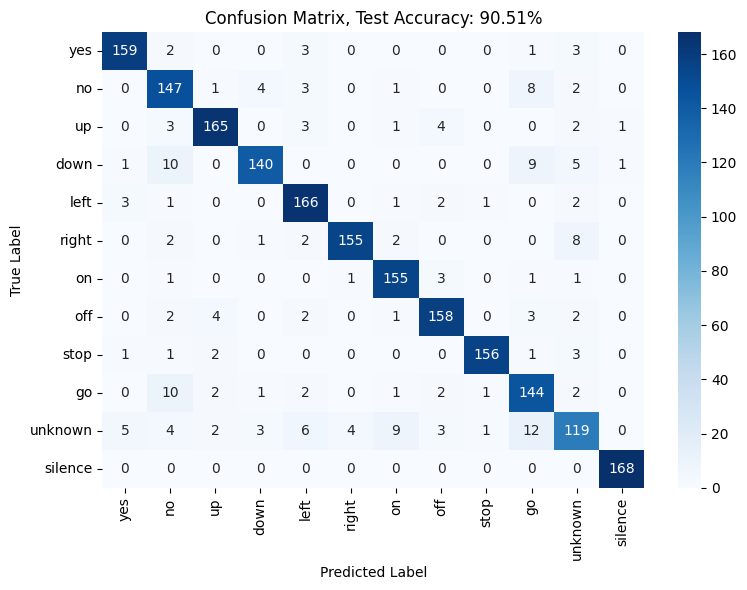

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from transformers import Trainer

# 1. Load the best model checkpoint automatically saved during training
#    (Trainer saves the best model if load_best_model_at_end=True in TrainingArguments)
#    If not, point to the best checkpoint manually:
# trainer.model = AutoModelForSequenceClassification.from_pretrained("./results/checkpoint-XXXX")

# 2. Run predictions on the test set
predictions_output = trainer.predict(test_ds)

logits = predictions_output.predictions          # raw logits, shape (N, num_labels)
labels = predictions_output.label_ids            # true labels, shape (N,)
preds  = np.argmax(logits, axis=-1)              # predicted class indices

# 3. Compute accuracy
accuracy = accuracy_score(labels, preds)
print(f"Test Accuracy: {accuracy:.4f}")

# 4. Full classification report
label_names = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go", "unknown", "silence"]  # ← replace with your actual label names
print(classification_report(labels, preds, target_names=label_names))

# 5. Confusion matrix
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax
)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Confusion Matrix, Test Accuracy: {accuracy:.2%}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()